# 1. IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# 2. DATA PREPROCESSING

In [2]:
# Load dataset
df = pd.read_csv('/content/data_ecommerce_customer_churn.csv')

print("Informasi Dataset")
print(df.info())
print("\n Deskripsi Statistik")
print(df.describe())

# Cek dan tangani Missing Values (Nilai yang kosong)
print("\n Missing Values Sebelum Imputasi")
print(df.isnull().sum())

# Mengisi missing value pada kolom numerik dengan nilai Median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Encoding variabel kategorik ('PreferedOrderCat' & 'MaritalStatus') dengan LabelEncoder
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB
None

 Deskripsi Statistik
            Tenure  WarehouseToHome  NumberOfDeviceRegistered  \
coun

/tmp/ipykernel_6355/360962970.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Output berupa Teks Informasi Dataset. Ditampilkan bahwa dataset Anda memiliki 3941 baris data pelanggan dan 11 kolom. Tampil juga daftar kolom yang memiliki data kosong sebelum akhirnya diisi otomatis oleh kode.

# 3. EXPLORATORY DATA ANALYSIS (EDA)

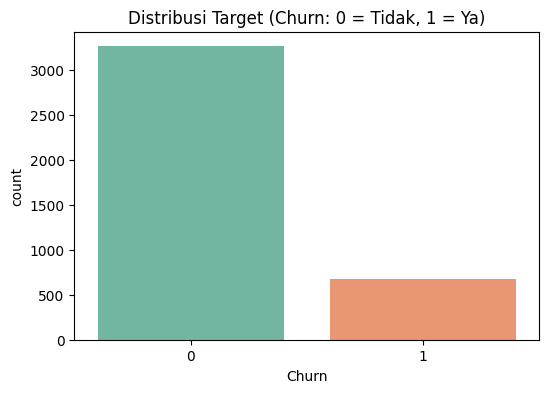

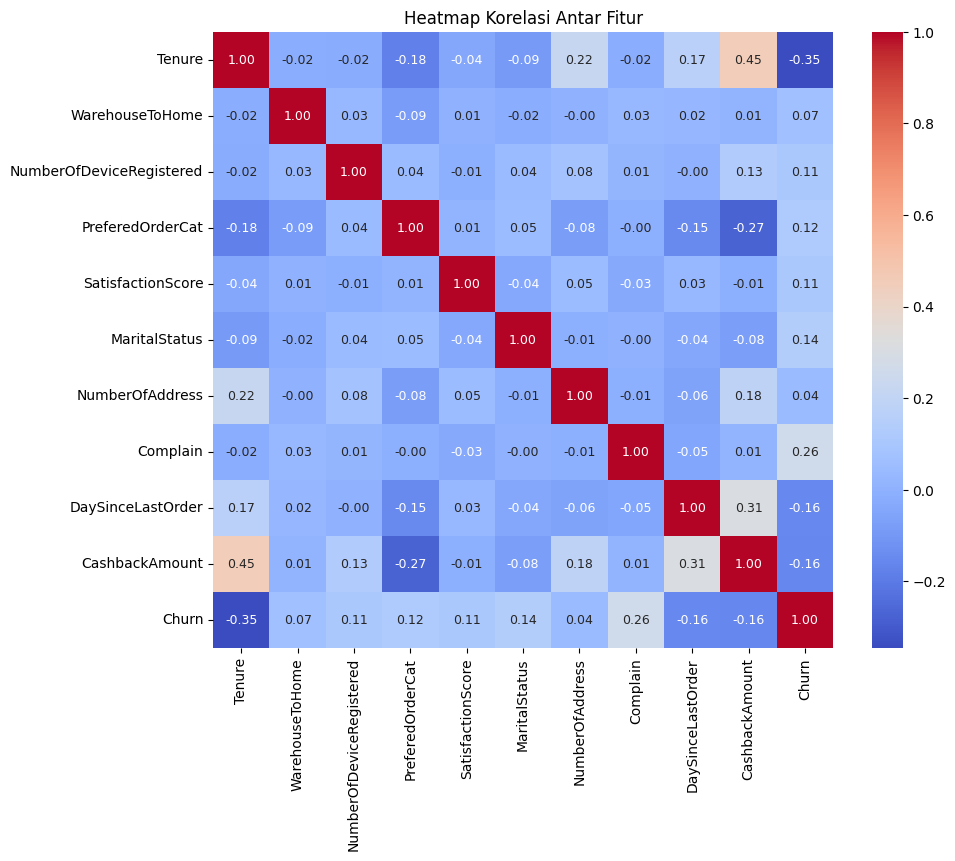

In [3]:
# Visualisasi 1: Distribusi Target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribusi Target (Churn: 0 = Tidak, 1 = Ya)')
plt.show()

# Visualisasi 2: Heatmap Korelasi
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 9})
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

**Grafik Countplot (Distribusi Target):**
Menampilkan diagram batang perbandingan pelanggan yang Churn (1) vs Tidak Churn (0). Terlihat jelas bahwa data ini imbalanced (tidak seimbang), di mana jumlah pelanggan yang bertahan (0) jauh lebih banyak daripada pelanggan yang pergi (1).

**Grafik Heatmap Korelasi:**
Menampilkan kotak berwarna dengan angka. Ini menunjukkan seberapa kuat hubungan antar satu variabel dengan variabel lain. Semakin mendekati angka 1 atau -1, maka hubungannya semakin kuat.

# 4. FEATURE SELECTION & SPLIT DATA

In [5]:
# Fitur (X) mencakup semua kolom kecuali 'Churn', Target (y) adalah 'Churn'
X = df.drop('Churn', axis=1)
y = df['Churn']

# Membagi data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
Membelah data menjadi dua kelompok. 80% Data Latih dan 20% Data Uji

# 5. FEATURE SCALING

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

StandardScaler digunakan agar semua fitur diseragamkan rentang skalanya sehingga model bisa menghitung jarak dengan adil.

Hasil dari proses ini adalah variabel data (X_train_scaled) yang nilainya sudah terstandarisasi/diperkecil rentangnya namun tetap mempertahankan polanya.

# 6. MODEL KNN & MENCARI K TERBAIK

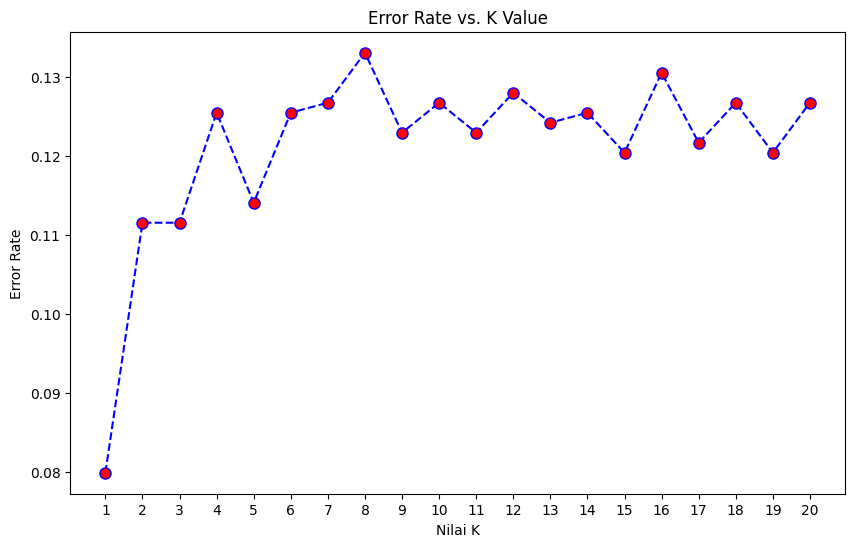


Nilai K terbaik berdasarkan Error Rate terendah adalah: 1


In [8]:
error_rates = []
k_values = range(1, 21) # Mengecek nilai K dari 1 hingga 20

for i in k_values:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rates.append(np.mean(pred_i != y_test))

# Visualisasi: Error Rate vs Nilai K
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('Nilai K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.show()

# Mendapatkan nilai K dengan Error Rate terkecil
best_k = k_values[np.argmin(error_rates)]
print(f"\nNilai K terbaik berdasarkan Error Rate terendah adalah: {best_k}")

KNN membutuhkan parameter K (jumlah tetangga/data terdekat yang digunakan untuk mengambil keputusan). Kode ini melakukan looping (perulangan) dari K=1 hingga K=20.

**Grafik Error Rate vs K Value:** Menampilkan grafik garis bersudut. Sumbu X adalah nilai K, dan Sumbu Y adalah tingkat error.

# 7. MODEL TRAINING (DENGAN K TERBAIK)

In [9]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

Setelah tahu K=1 adalah yang terbaik, komputer merakit ulang model KNeighborsClassifier(n_neighbors=best_k). Lalu dilakukan fit (belajar dari 80% data latih) dan dilanjutkan dengan predict (disuruh menebak 20% data uji).

Output dari langkah ini tersimpan secara internal di dalam variabel bernama y_pred (kumpulan tebakan si model).

# 8. EVALUASI MODEL


 Laporan Klasifikasi (Classification Report)
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       654
           1       0.81      0.70      0.75       135

    accuracy                           0.92       789
   macro avg       0.87      0.83      0.85       789
weighted avg       0.92      0.92      0.92       789

Accuracy  : 0.9201520912547528
Precision : 0.8103448275862069
Recall    : 0.6962962962962963
F1-Score  : 0.749003984063745


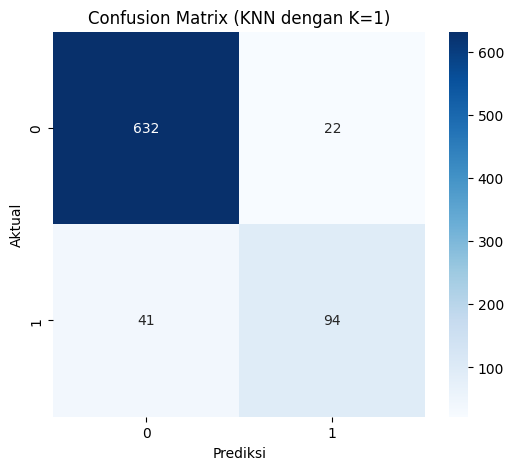

In [10]:
print("\n Laporan Klasifikasi (Classification Report)")
print(classification_report(y_test, y_pred))

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1-Score  :", f1_score(y_test, y_pred))

# Visualisasi: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (KNN dengan K={best_k})')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Menampilkan hasil metrik evaluasi berupa angka.
* Accuracy: 92% (Tebakan secara keseluruhan benar 92%).
* Precision (untuk kelas Churn=1): 81% (Saat model menebak seseorang akan Churn, persentase tebakannya itu benar adalah 81%).
* Recall (untuk kelas Churn=1): 70% (Dari semua pelanggan yang diam-diam ternyata Churn, model cuma berhasil mencegat/mendeteksi 70%-nya saja).

Berdasarkan gambar tersebut, model berhasil menebak dengan tepat 613 pelanggan yang bertahan dan 94 pelanggan yang churn, namun keliru memprediksi 41 pelanggan aman sebagai churn serta gagal mendeteksi 41 pelanggan yang sebenarnya churn.